# Part 4: Vector Database & Embeddings Demo
Requirements:
- Google Colab
- Write 10 sentences across 3 topics
- Generate embeddings using `sentence-transformers`
- Compute and display a 10x10 cosine similarity matrix as a heatmap
- Query a new sentence

In [1]:
!pip install sentence-transformers pandas seaborn matplotlib numpy

In [2]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Load the model
model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [3]:
# 2. Define exactly 10 sentences across 3 topics (Cricket, Cooking, Cybersecurity)
sentences = [
    # Cricket (3)
    "The batsman played a beautiful cover drive for a boundary.",
    "The spin bowler completely confused the opening batsman with a googly.",
    "The team needs 12 runs from the final over to win the match.",

    # Cooking (4)
    "Simmer the tomato sauce on low heat for an hour to develop flavors.",
    "To make a perfect omelette, whisk the eggs until they are extremely fluffy.",
    "You should always rest your steak for five minutes after grilling.",
    "Dicing onions evenly ensures that they cook at the exact same rate.",

    # Cybersecurity (3)
    "A distributed denial of service attack overwhelmed the company servers.",
    "Multi-factor authentication prevents unauthorized access even if passwords are leaked.",
    "The hacker exploited a zero-day vulnerability in the firewall operating system."
]

# 3. Generate Embeddings
embeddings = model.encode(sentences)

print(f"Successfully generated {len(embeddings)} embeddings of dimension {len(embeddings[0])}.")

Successfully generated 10 embeddings of dimension 384.


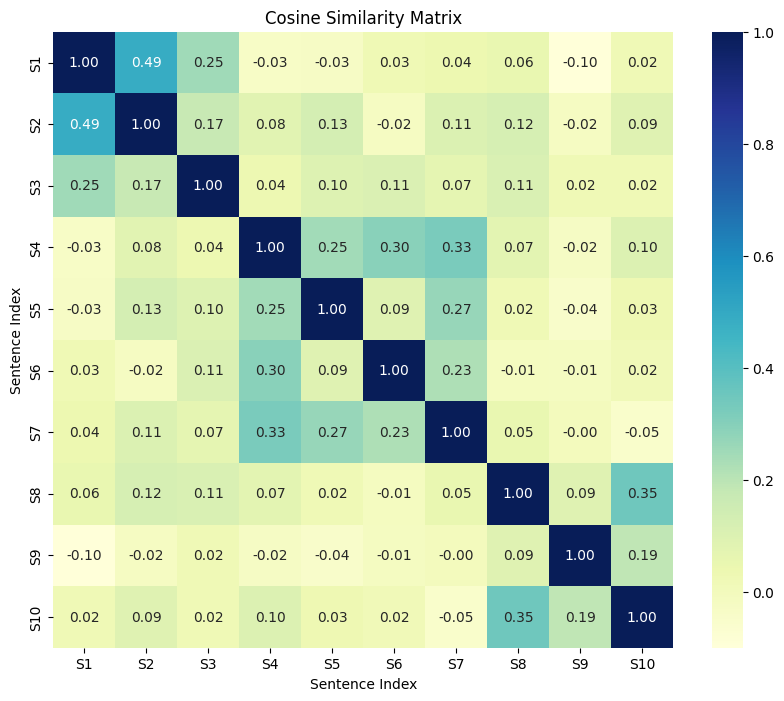

In [4]:
# 4. Compute and display 10x10 cosine similarity matrix
similarity_matrix = cosine_similarity(embeddings)

# Plotting the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    similarity_matrix,
    annot=True,
    cmap="YlGnBu",
    xticklabels=[f"S{i+1}" for i in range(10)],
    yticklabels=[f"S{i+1}" for i in range(10)],
    fmt=".2f"
)
plt.title("Cosine Similarity Matrix")
plt.xlabel("Sentence Index")
plt.ylabel("Sentence Index")
plt.show()

In [5]:
# 5. Querying the Vector Database
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

# Compute similarities against all existing sentences
query_similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 most similar indices
top_2_idx = np.argsort(query_similarities)[-2:][::-1]

print(f"Query: '{query}'\n")
print("Top 2 Most Similar Sentences:")
for idx in top_2_idx:
    print(f"Score: {query_similarities[idx]:.4f} | Sentence: '{sentences[idx]}'")

Query: 'The bowler took three wickets in one over'

Top 2 Most Similar Sentences:
Score: 0.5224 | Sentence: 'The spin bowler completely confused the opening batsman with a googly.'
Score: 0.4674 | Sentence: 'The batsman played a beautiful cover drive for a boundary.'
